Evaluace vyladěných modelů:


In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd
from joblib import load
from sklearn.model_selection import train_test_split
import numpy as np


In [2]:
#nacteni pipeline
preprocessor = load("preprocessor.joblib")
#nacteni dat
df = pd.read_csv("netflix_customer_churn.csv")
#normalizace dat
# Odstranění duplicit
df = df.drop_duplicates()

# Normalizace textových hodnot
text_cols = [
    "gender",
    "subscription_type",
    "region",
    "device",
    "payment_method",
    "favorite_genre"
]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Logicky nesmyslné hodnoty → NaN
df.loc[(df["age"] < 0) | (df["age"] > 120), "age"] = np.nan

df.loc[df["watch_hours"] < 0, "watch_hours"] = np.nan
df.loc[df["avg_watch_time_per_day"] < 0, "avg_watch_time_per_day"] = np.nan

df.loc[df["last_login_days"] < 0, "last_login_days"] = np.nan

df.loc[df["number_of_profiles"] < 0, "number_of_profiles"] = np.nan

df.loc[df["monthly_fee"] < 0, "monthly_fee"] = np.nan

df.isna().sum()
#split dat
X = df.drop(columns=["churned", "customer_id"])
y = df["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#aplikace preprocessing pipeline
X_train_prepared = preprocessor.transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

Logistická regrese nebyla laděna, přesto je zahrnuta jako základní model se kterým budou porovnávány metriky ostatních

In [3]:
#logistická regrese
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)
#trénování na datech
log_reg.fit(X_train_prepared, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Decision Tree:

In [4]:
dt_final = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=20,
    random_state=42
)

# Trénink na celých trénovacích datech
dt_final.fit(X_train_prepared, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,20
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Random Forest:

In [5]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=16,
    max_features="log2",
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

# Trénink na celých trénovacích datech
rf_final.fit(X_train_prepared, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,16
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Gradient boosting:

In [6]:
gb_final = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.2,
    max_depth=2,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)

# Trénink na celých trénovacích datech
gb_final.fit(X_train_prepared, y_train)

,loss,'log_loss'
,learning_rate,0.2
,n_estimators,300
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


Evaluační funkce:

In [7]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }

In [8]:
results = {
    "Logistic Regression": evaluate(log_reg, X_test_prepared, y_test),
    "Decision Tree": evaluate(dt_final, X_test_prepared, y_test),
    "Random Forest": evaluate(rf_final, X_test_prepared, y_test),
    "Gradient Boosting": evaluate(gb_final, X_test_prepared, y_test),
}

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1,ROC AUC
Logistic Regression,0.891,0.875954,0.912525,0.893866,0.968579
Decision Tree,0.979,0.985887,0.972167,0.978979,0.994614
Random Forest,0.982,0.987928,0.976143,0.982000,0.997770
Gradient Boosting,0.995,0.998000,0.992048,0.995015,0.999028


ROC křivky:

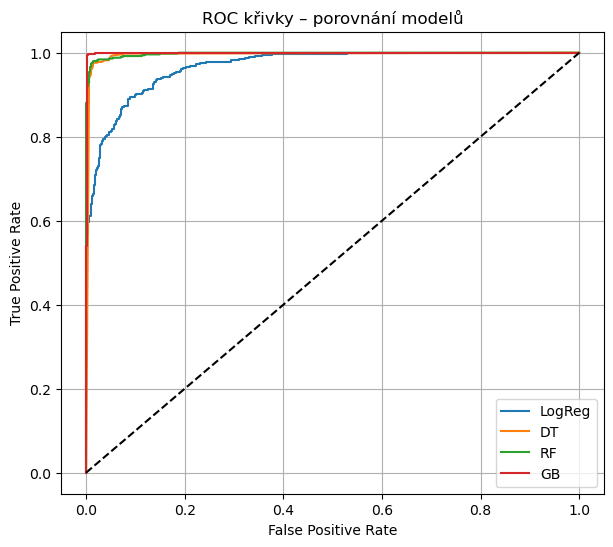

In [9]:
models = {
    "LogReg": log_reg,
    "DT": dt_final,
    "RF": rf_final,
    "GB": gb_final
}

plt.figure(figsize=(7, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test_prepared)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC křivky – porovnání modelů")
plt.legend()
plt.grid(True)
plt.show()

Feature importance:

In [10]:
feature_names = preprocessor.get_feature_names_out()

Logreg:

In [11]:
logreg_importance = pd.Series(
    log_reg.coef_[0],
    index=feature_names
).sort_values(key=np.abs, ascending=False)

logreg_importance.head(5)

num__last_login_days            3.355793
num__watch_hours               -3.244270
num__avg_watch_time_per_day    -2.181136
num__number_of_profiles        -1.630937
cat__subscription_type_Basic    1.173371
dtype: float64

Rozhodovací strom

In [12]:
dt_importance = pd.Series(
    dt_final.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

dt_importance.head(5)

num__avg_watch_time_per_day    0.599955
num__number_of_profiles        0.077710
num__watch_hours               0.077221
num__monthly_fee               0.071635
num__last_login_days           0.071311
dtype: float64

Decision Tree

In [13]:
rf_importance = pd.Series(
    rf_final.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

rf_importance.head(5)

num__avg_watch_time_per_day    0.352765
num__watch_hours               0.202279
num__last_login_days           0.178029
num__number_of_profiles        0.060854
num__age                       0.027947
dtype: float64

Gradient Boosting

In [14]:
gb_importance = pd.Series(
    gb_final.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

gb_importance.head(5)


num__avg_watch_time_per_day     0.674846
num__last_login_days            0.097150
num__watch_hours                0.078435
num__number_of_profiles         0.076867
cat__subscription_type_Basic    0.027916
dtype: float64

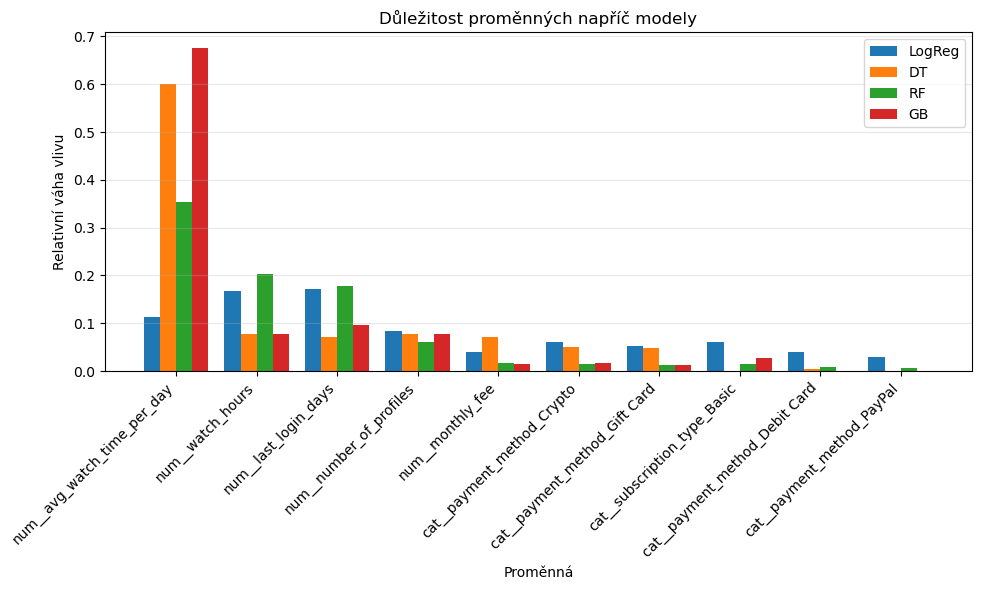

In [15]:
# normalizace
def normalize(s):
    return s / s.sum()

importance_df = pd.DataFrame({
    "LogReg": normalize(logreg_importance.abs()),
    "DT": normalize(dt_importance),
    "RF": normalize(rf_importance),
    "GB": normalize(gb_importance)
}).fillna(0)

importance_df["mean"] = importance_df.mean(axis=1)
importance_sorted = importance_df.sort_values("mean", ascending=False)

# top N proměnných
TOP_N = 10
importance_top = importance_sorted.head(TOP_N)

colors = {
    "LogReg": "#1f77b4",
    "DT": "#ff7f0e",
    "RF": "#2ca02c",
    "GB": "#d62728"
}

plt.figure(figsize=(10, 6))
x = np.arange(len(importance_top))
w = 0.2

for i, model in enumerate(["LogReg", "DT", "RF", "GB"]):
    plt.bar(x + i*w, importance_top[model], w, label=model, color=colors[model])

plt.xticks(x + 1.5*w, importance_top.index, rotation=45, ha="right")
plt.ylabel("Relativní váha vlivu")
plt.xlabel("Proměnná")
plt.title("Důležitost proměnných napříč modely")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
